# k-means Clustering

## Table of contents

[1.) Simple k-means clustering example](#section_1)<br>
[2.) Image segmentation](#section_2)<br>
[3.) 3D point cloud segmentation](#section_3)<br>
[4.) Finding clusters in the apartment data](#section_4)

## Libraries and settings

In [1]:
# Install opencv-python-headless (neccessary in GitHub Codespaces)
!pip install --upgrade pip
!pip install opencv-python-headless

# Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Current working directory
print('\nCurrent working directory:', os.getcwd())

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable

Current working directory: /workspaces/data_analytics/Week_10


## 1.) Simple k-means clustering example
<a id='section_1'></a>

### Create the dataset

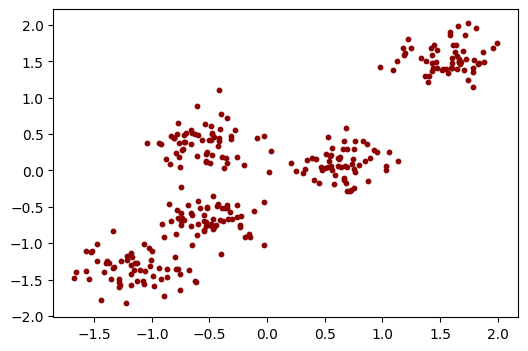

In [2]:
# Create data
centers = [[2,1], [-2,2], [-2,-2], [-4,-5], [5,7]]
X, y = make_blobs(n_samples=300, 
                  centers=centers, 
                  cluster_std=0.8,
                  random_state=42)

# Normalization of the values
X = StandardScaler().fit_transform(X)

# Plot the data
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], s=10, color='darkred')
plt.show()

### Elbow Method showing the optimal k

#### Task 1b: Answer - Optimal k based on Elbow Method

**Based on the elbow chart above, the optimal value of k is 5.**

The elbow method shows that the distortion (within-cluster sum-of-squares) decreases rapidly from k=1 to k=5. At k=5, we can observe an "elbow" where the rate of decrease slows down significantly. This indicates that k=5 provides a good balance between model complexity and clustering quality. Adding more clusters beyond k=5 does not significantly reduce the distortion.

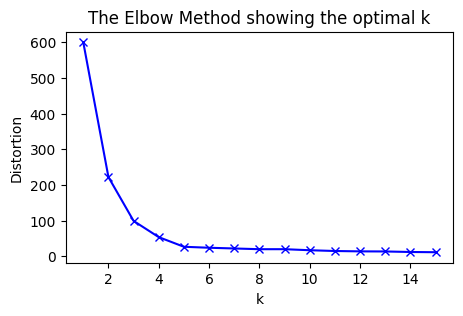

In [3]:
# Sum of squared distances of samples to their closest cluster center
distortions = []

# Range of k's
K = range(1,16,1)

# Loop to find the optimal k
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    distortions.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')

plt.show()

### Perform k-means clustering

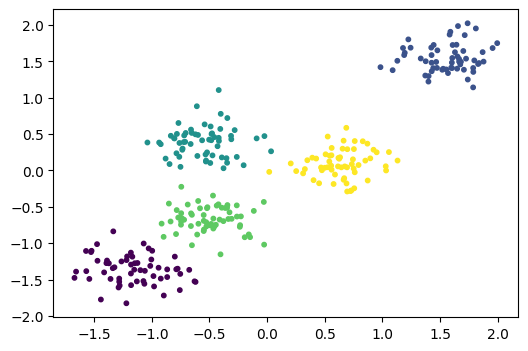

In [4]:
# Number of clusters
k = 5

# k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)

# Predict the values
y2 = kmeans.predict(X)

# Plot the clusters
plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], X[:, 1], c=y2, s=10)
plt.show()

### Get and check the converged cluster centroids

In [5]:
# Print centroids
centroids = kmeans.cluster_centers_
print('Cluster centroids:')
print(centroids, '\n')

# Check the 1st cluster's centroid 'by hand'
clust_00 = X[y2 == 0]
print('The 1st cluster\'s centroid:')
print(f'x = {sum(clust_00[:,0]/len(clust_00[:,0])):.8f}')
print(f'y = {sum(clust_00[:,1]/len(clust_00[:,1])):.8f}')

Cluster centroids:
[[-1.16214999 -1.36217282]
 [ 1.56276666  1.54186443]
 [-0.55467879  0.3889481 ]
 [-0.49867406 -0.67040574]
 [ 0.64167824  0.09023659]] 

The 1st cluster's centroid:
x = -1.16214999
y = -1.36217282


### Get the inertia or 'within-cluster sum-of-squares (WCSS)' of the k-means model

In [6]:
print(f'Within-cluster sum-of-squares: {kmeans.inertia_:.4f}')

Within-cluster sum-of-squares: 26.3487


### Perform Silhouette Analysis
- For examples see:
- https://laid-back-scientist.com/en/k-means
- https://machinelearninggeek.com/evaluating-clustering-methods
- https://medium.com/@favourphilic/how-to-interpret-silhouette-plot-for-k-means-clustering-414e144a17fe

k=2, Silhouette Score: 0.5325


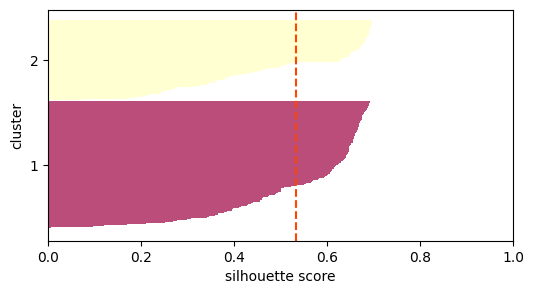

k=3, Silhouette Score: 0.5659


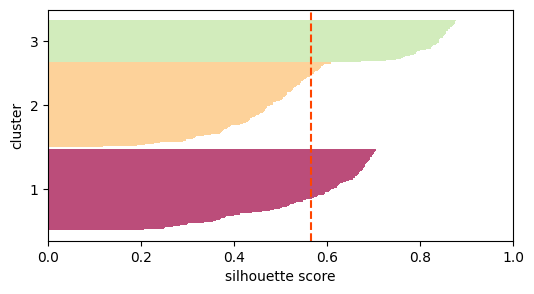

k=4, Silhouette Score: 0.6257


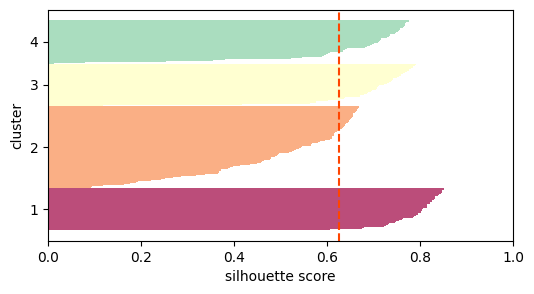

k=5, Silhouette Score: 0.6597


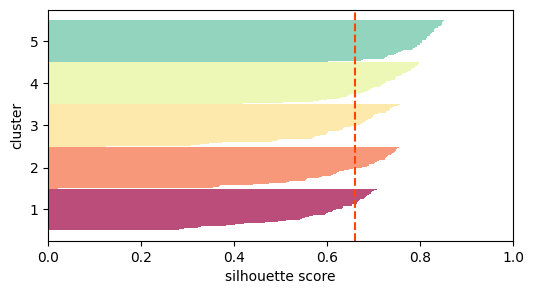

k=6, Silhouette Score: 0.6110


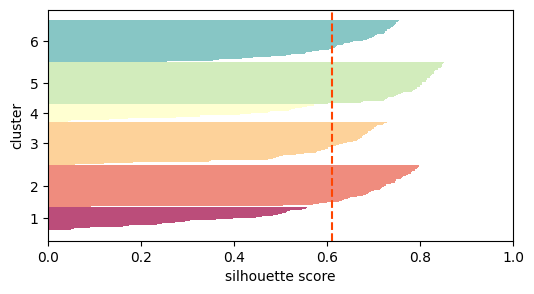

k=7, Silhouette Score: 0.5223


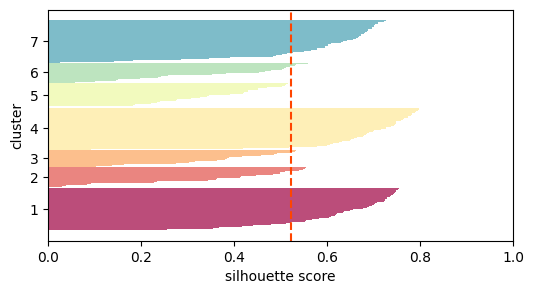

k=8, Silhouette Score: 0.4926


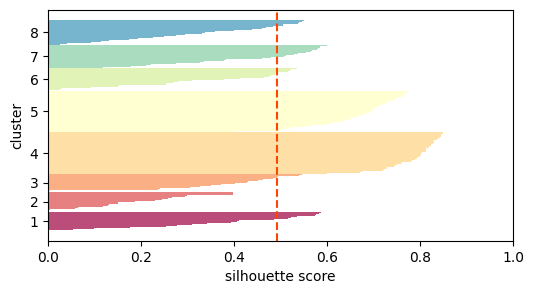

k=9, Silhouette Score: 0.4076


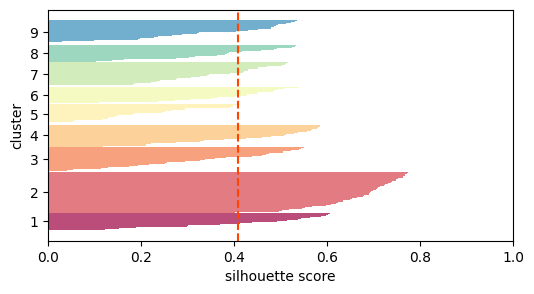

k=10, Silhouette Score: 0.4020


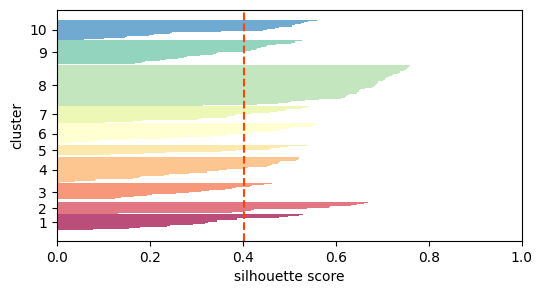

k=11, Silhouette Score: 0.3349


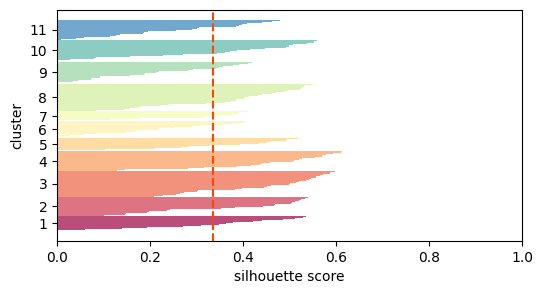

In [7]:
# Import own module for Silhouette plots
from silhouette import *

# Create Silhouette plots for different k's
# Note: range(2,12,1) provides: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
# Task 1c: Changed from [2,3] to range(2,12,1) to analyze k=2 through k=11
for i in range(2,12,1):
    model = KMeans(n_clusters=i, 
                   random_state=42, 
                   init='random')
    model.fit(X)
    print(f'k={i}, Silhouette Score: {silhouette_score(X, model.labels_):.4f}')
    plt.figure(figsize=(6,3))
    show_silhouette(X=X, fitted_model=model)

## 2.) Image segmentation
<a id='section_2'></a>

### Read the image

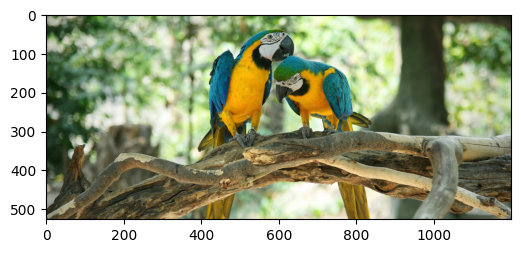

In [8]:
# Read the image
image = cv2.imread('parrot.jpg')
 
# Change the color to RGB (from BGR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot the image
plt.figure(figsize=(6,8))
plt.imshow(image)

### Reshape the image

In [9]:
# Reshaping the image into a 2D array of pixels and RGB colors
pixel_vals = image.reshape((-1,3))
 
# Convert to float
pixel_vals = np.float32(pixel_vals)
pixel_vals

array([[ 37.,  68.,  37.],
       [ 37.,  70.,  39.],
       [ 43.,  76.,  45.],
       ...,
       [102., 112., 113.],
       [102., 114., 114.],
       [102., 114., 114.]], shape=(632400, 3), dtype=float32)

### Elbow method showing the optimal k

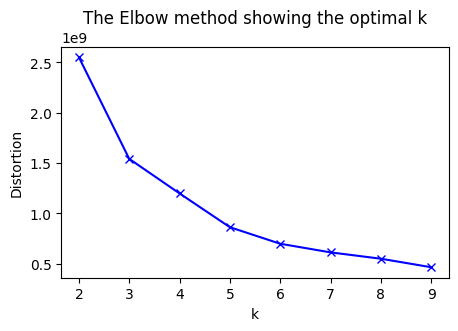

In [10]:
# Sum of squared distances of samples to their closest cluster center
distortions = []

# Range of k's
K = range(2,10,1)

# Loop to find the optimal k
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(pixel_vals)
    distortions.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow method showing the optimal k')

plt.show()

### Perform image segmentation

In [11]:
# Number of clusters
k = 5

# Criteria for the segmentation algorithm to stop running
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)
 
# Perform k-means clustering
retval, labels, centers = cv2.kmeans(pixel_vals, 
                                     k, 
                                     None, 
                                     criteria, 
                                     10, 
                                     cv2.KMEANS_RANDOM_CENTERS)

# Print cluster labels
print('Cluster labels:')
print(labels, '\n')

# Print cluster centroids
print(f'Centroids of {k} clusters')
print(centers)

Cluster labels:
[[2]
 [2]
 [2]
 ...
 [4]
 [4]
 [4]] 

Centroids of 5 clusters
[[161.7978   176.42497  131.57068 ]
 [206.1085   142.65912   10.698247]
 [ 53.6455    63.024746  40.379005]
 [217.82266  229.63536  192.77307 ]
 [104.76609  113.03692   78.56786 ]]


### Change data types and reshape the segmented data for visualization

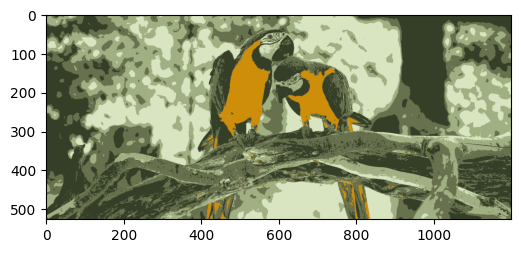

In [12]:
# Convert data into 8-bit values
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
 
# Reshape data into the original image dimensions
segmented_image = segmented_data.reshape((image.shape))

# Show result
plt.figure(figsize=(6,8))
plt.imshow(segmented_image)

### Task 1d-f: Image segmentation with own image (deutz_d15.jpg)

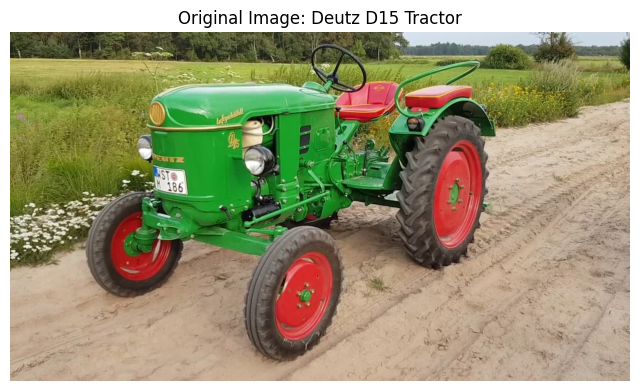

In [13]:
# Task 1d: Read own image (deutz_d15.jpg)
image_own = cv2.imread('deutz_d15.jpg')
 
# Change the color to RGB (from BGR)
image_own = cv2.cvtColor(image_own, cv2.COLOR_BGR2RGB)

# Plot the image
plt.figure(figsize=(8,6))
plt.title('Original Image: Deutz D15 Tractor')
plt.imshow(image_own)
plt.axis('off')
plt.show()

In [14]:
# Reshape the image into a 2D array of pixels and RGB colors
pixel_vals_own = image_own.reshape((-1,3))
 
# Convert to float
pixel_vals_own = np.float32(pixel_vals_own)
print(f'Shape of pixel array: {pixel_vals_own.shape}')

Shape of pixel array: (921600, 3)


#### Task 1e: Elbow method for own image

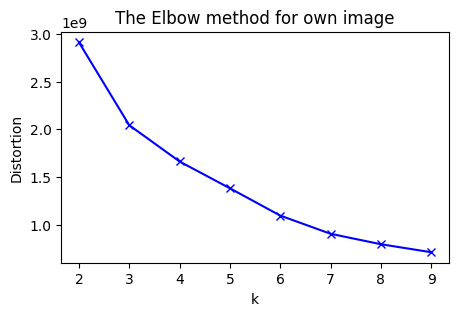


Based on the elbow chart, the optimal k appears to be around 3-4.
The curve shows a clear elbow around k=3 or k=4.


In [15]:
# Task 1e: Sum of squared distances of samples to their closest cluster center
distortions_own = []

# Range of k's
K_own = range(2,10,1)

# Loop to find the optimal k
for k in K_own:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(pixel_vals_own)
    distortions_own.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K_own, distortions_own, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow method for own image')
plt.show()

print('\nBased on the elbow chart, the optimal k appears to be around 3-4.')
print('The curve shows a clear elbow around k=3 or k=4.')

#### Task 1f: 4 different image segmentations with different k values

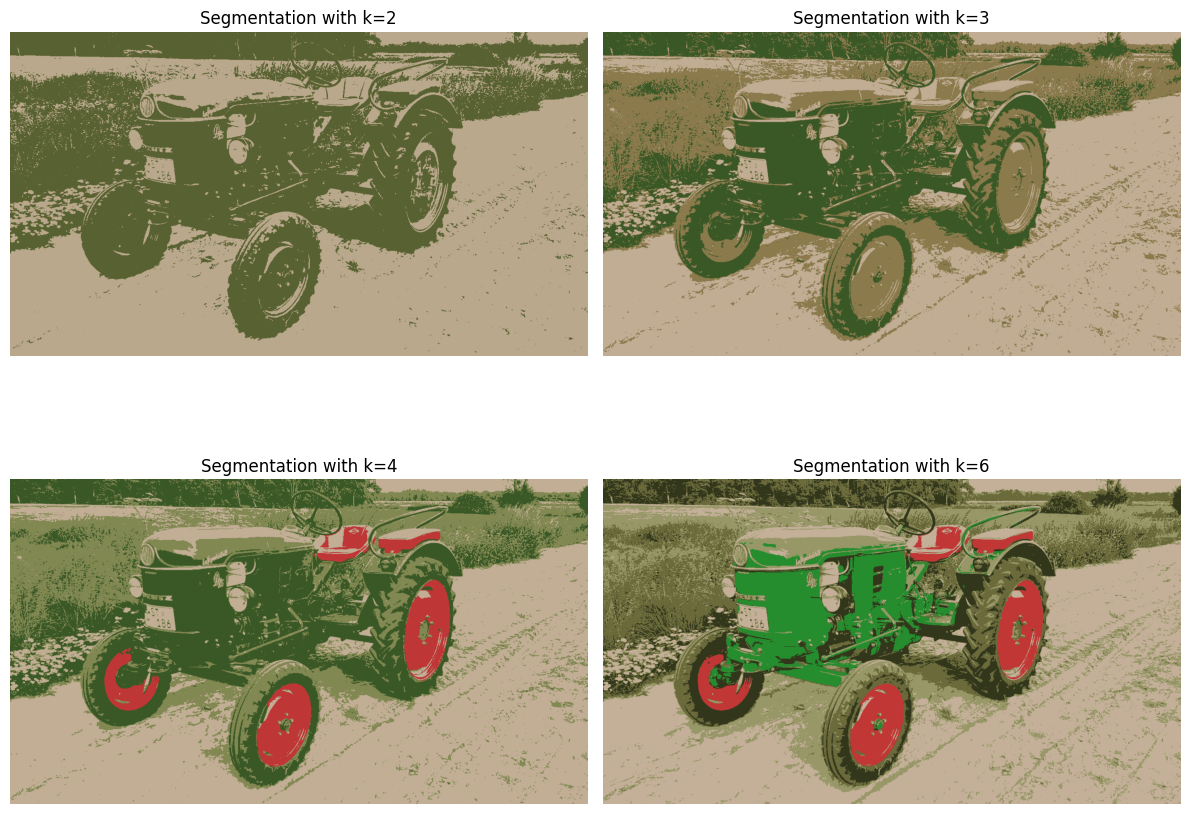


Observations:
- k=2: Very simple segmentation with only 2 colors, loses most details
- k=3: Basic segmentation that separates main color regions
- k=4: Good balance between simplification and detail preservation
- k=6: More detailed segmentation, captures more color variations


In [16]:
# Task 1f: Create 4 different segmentations with k=2, 3, 4, and 6
k_values = [2, 3, 4, 6]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    # Criteria for the segmentation algorithm
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)
    
    # Perform k-means clustering
    retval, labels, centers = cv2.kmeans(pixel_vals_own, 
                                         k, 
                                         None, 
                                         criteria, 
                                         10, 
                                         cv2.KMEANS_RANDOM_CENTERS)
    
    # Convert data into 8-bit values
    centers = np.uint8(centers)
    segmented_data = centers[labels.flatten()]
    
    # Reshape data into the original image dimensions
    segmented_image = segmented_data.reshape((image_own.shape))
    
    # Plot
    axes[idx].imshow(segmented_image)
    axes[idx].set_title(f'Segmentation with k={k}', fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print('\nObservations:')
print('- k=2: Very simple segmentation with only 2 colors, loses most details')
print('- k=3: Basic segmentation that separates main color regions')
print('- k=4: Good balance between simplification and detail preservation')
print('- k=6: More detailed segmentation, captures more color variations')

## 3.) 3D point cloud segmentation
- For details see: https://towardsdatascience.com/3d-point-cloud-clustering-tutorial-with-k-means-and-python-c870089f3af8
- Data-Viewer: https://app.flyvast.com/flyvast/app/page-snapshot-viewer.html#/444/9b557b91-8f41-16fa-cd2d-3476a1756611
<a id='section_3'></a>

### Import the data (Airport LIDAR point cloud dataset)

In [17]:
# Import the data
data = "KME_planes.xyz"
x, y, z, illuminance, reflectance, intensity, nb_of_returns = np.loadtxt(data,
                                                                         skiprows=1, 
                                                                         delimiter=';', 
                                                                         unpack=True)
# Array with positions of points
pcd = np.column_stack((x,y,z))

# Mean of z-variable (height above ground)
print(np.mean(z).round(4))

# Subset of the point cloud 
mask = (z > np.mean(z)) & (x <= 320) & (x >= 230)
spatial_query = pcd[mask]
spatial_query.shape

5.2829


(9676, 3)

### 3D plot of the point cloud subset

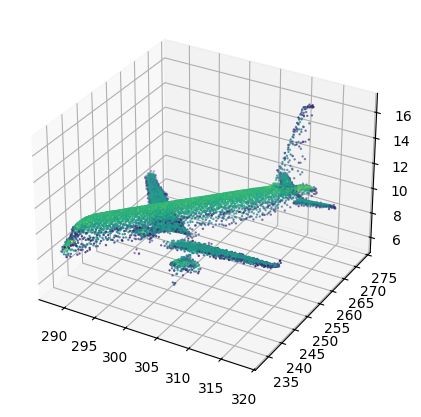

In [18]:
# 3D plot of the subset
plt.figure(figsize=(5,5))
ax = plt.axes(projection ='3d')
ax.scatter(x[mask], y[mask], z[mask], c=intensity[mask], s=0.5)
plt.show()

### 2D plot of the point cloud subset

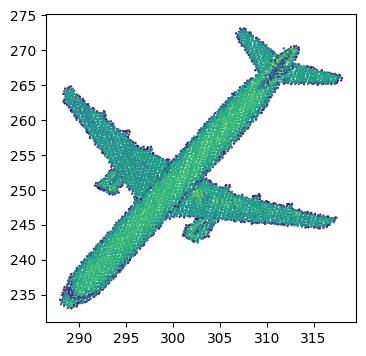

In [19]:
# 2D plot of the subset
plt.figure(figsize=(4,4))
plt.scatter(x[mask], y[mask], c=intensity[mask], s=0.5)
plt.show()

### Elbow method showing the optimal k

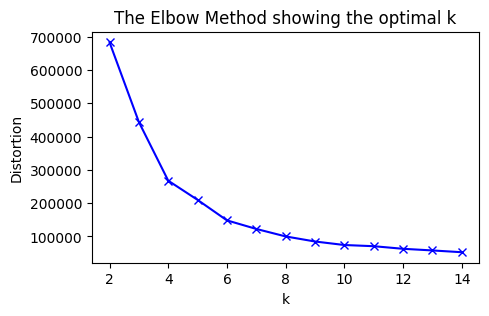

In [20]:
# Sum of squared distances of samples to their closest cluster center
distortions = []

# Range of k's
K = range(2,15,1)

# Loop to find the optimal k
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(spatial_query)
    distortions.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')

plt.show()

### Point cloud segmentation based on k-means clustering

In [21]:
# Define number of clusters
k = 5

# Stack with x,y,z values
X2 = np.column_stack((x[mask], y[mask], z[mask]))

# Perform k-means clustering
kmeans_aerpl = KMeans(n_clusters=k, random_state=42).fit(X2)

### 2D plot of the segmented point cloud

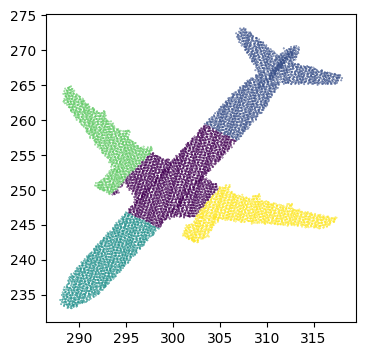

In [22]:
# 2D plot of image segmentation
plt.figure(figsize=(4,4))
plt.scatter(x[mask], y[mask], c=kmeans_aerpl.labels_, s = 0.1)
plt.show()

### 3D plot of the segmented point cloud

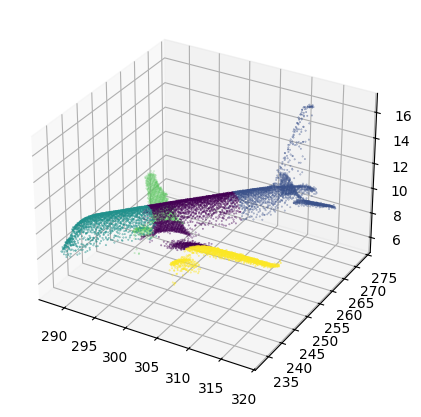

In [23]:
# 3D plot of image segmentation
plt.figure(figsize=(5,5))
ax = plt.axes(projection ='3d')
ax.scatter(x[mask], y[mask], z[mask], c=kmeans_aerpl.labels_, s=0.1)
plt.show()

### Calculate the Silhouette Score

In [24]:
print(f'Silhouette Score: {silhouette_score(X2, kmeans_aerpl.labels_):.4f}')

Silhouette Score: 0.4704


### Task 1h: Different k values for 3D point cloud segmentation

k=3: Silhouette Score = 0.4405
k=5: Silhouette Score = 0.4704
k=7: Silhouette Score = 0.4328
k=9: Silhouette Score = 0.4220


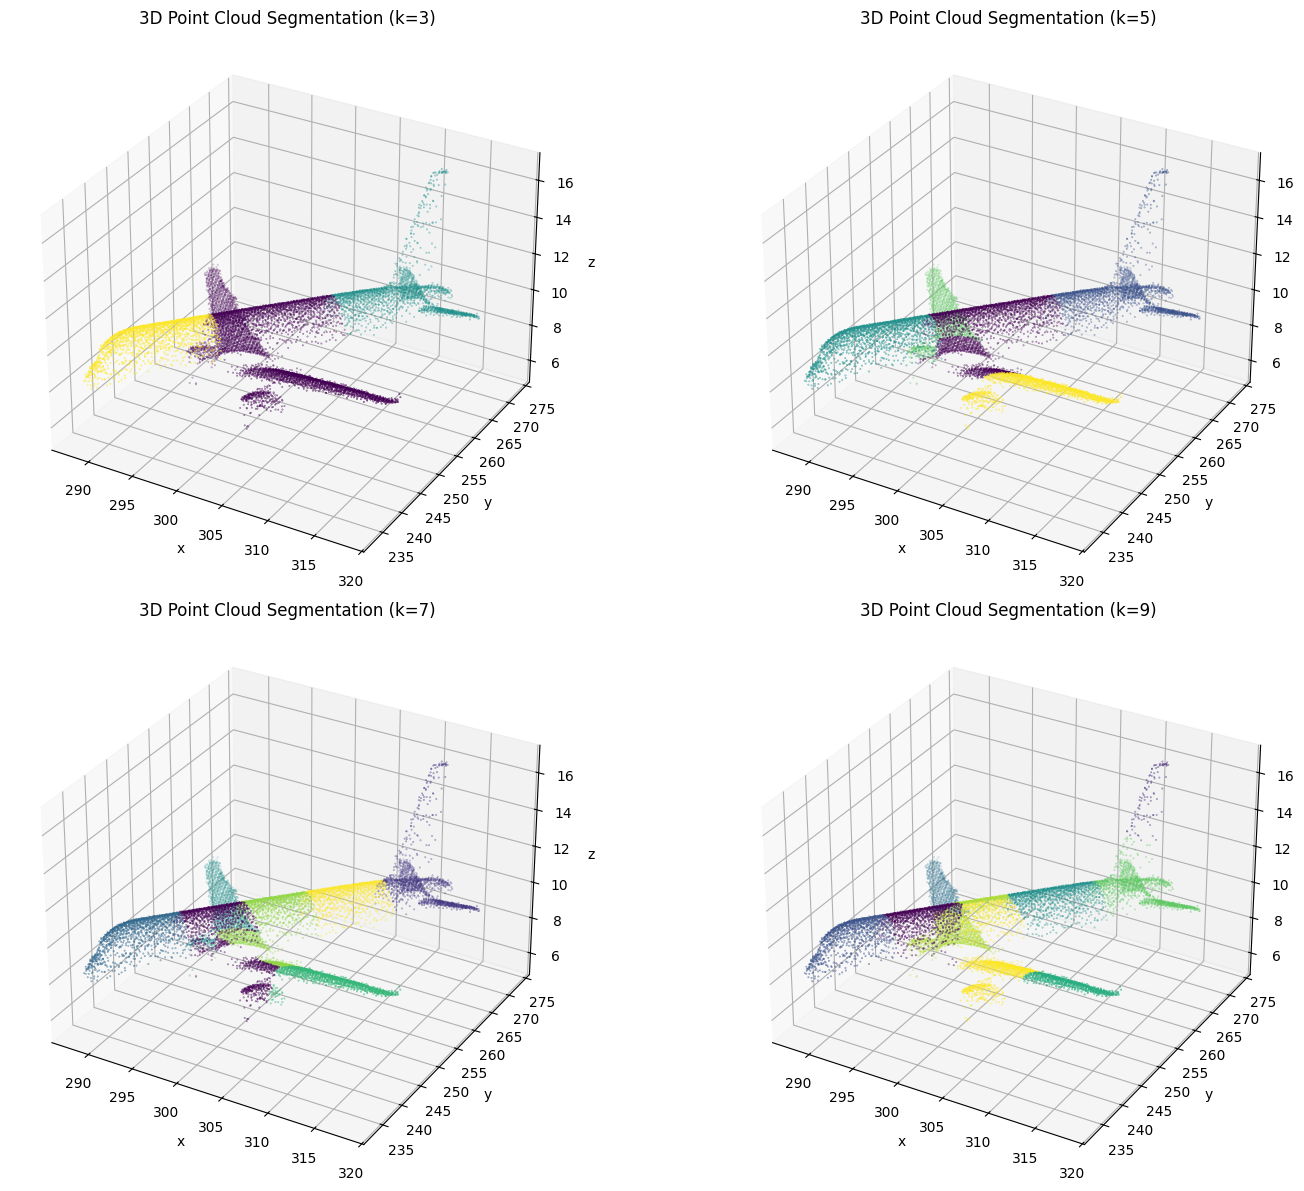


--- Task 1h: Observations ---
By changing the value of k, we can observe the following:
- k=3: The point cloud is divided into 3 main segments, likely representing
  major structures (e.g., different aircraft or ground areas)
- k=5: More fine-grained segmentation, separating individual aircraft or
  aircraft parts more clearly
- k=7: Even more detailed segmentation, potentially identifying smaller
  structures like wings, fuselage, etc.
- k=9: Very detailed segmentation, but may start to over-segment the data

The optimal k (around 5-6 based on the elbow method) provides a good balance
between identifying distinct structures without over-segmenting the point cloud.


In [25]:
# Task 1h: Test different k values for 3D point cloud segmentation
k_values_3d = [3, 5, 7, 9]

fig = plt.figure(figsize=(16, 12))

for idx, k in enumerate(k_values_3d, 1):
    # Perform k-means clustering with different k values
    kmeans_test = KMeans(n_clusters=k, random_state=42).fit(X2)
    
    # Create 3D subplot
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    ax.scatter(x[mask], y[mask], z[mask], c=kmeans_test.labels_, s=0.1, cmap='viridis')
    ax.set_title(f'3D Point Cloud Segmentation (k={k})', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    # Calculate and print Silhouette Score
    sil_score = silhouette_score(X2, kmeans_test.labels_)
    print(f'k={k}: Silhouette Score = {sil_score:.4f}')

plt.tight_layout()
plt.show()

print('\n--- Task 1h: Observations ---')
print('By changing the value of k, we can observe the following:')
print('- k=3: The point cloud is divided into 3 main segments, likely representing')
print('  major structures (e.g., different aircraft or ground areas)')
print('- k=5: More fine-grained segmentation, separating individual aircraft or')
print('  aircraft parts more clearly')
print('- k=7: Even more detailed segmentation, potentially identifying smaller')
print('  structures like wings, fuselage, etc.')
print('- k=9: Very detailed segmentation, but may start to over-segment the data')
print('')
print('The optimal k (around 5-6 based on the elbow method) provides a good balance')
print('between identifying distinct structures without over-segmenting the point cloud.')

## 4.) Finding clusters in the apartment data
<a id='section_4'></a>

### Import the apartment data

In [26]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";", encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


### Subset of the apartment data frame for k-means clustering

In [27]:
# Task 2b: Define a subset of the data frame for k-means clustering
# Extended with additional numerical variables: lat, lon, pop_dens, mean_taxable_income
X3 = df[['rooms',
         'area',
         'price_per_m2',
         'lat',
         'lon',
         'pop_dens',
         'mean_taxable_income']]

print('Extended feature set for k-means clustering:')
print(X3.columns.tolist())
print(f'\nShape of X3: {X3.shape}')
X3.head()

Extended feature set for k-means clustering:
['rooms', 'area', 'price_per_m2', 'lat', 'lon', 'pop_dens', 'mean_taxable_income']

Shape of X3: (722, 7)


,rooms,area,price_per_m2,lat,lon,pop_dens,mean_taxable_income
0,3.0,49,29.41,47.252171,8.845797,1221.272366,65362.04268
1,3.0,111,23.42,47.252087,8.854919,1221.272366,65362.04268
2,3.0,58,25.69,47.253670,8.853993,1221.272366,65362.04268
3,4.0,118,27.46,47.259834,8.851705,1221.272366,65362.04268
4,3.0,66,21.97,47.266113,8.866872,1221.272366,65362.04268


### Task 2c: Elbow method showing the optimal k for extended features

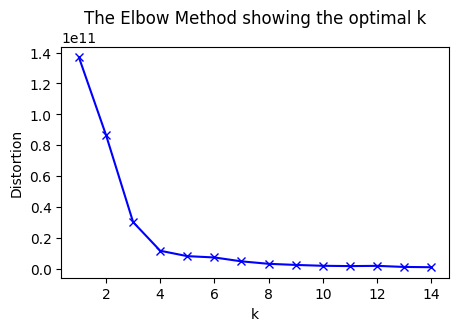

In [28]:
# Sum of squared distances of samples to their closest cluster center
distortions = []

# Range of k's
K = range(1,15)

# Loop to find the optimal k
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X3)
    distortions.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')

plt.show()

**Optimal k based on Elbow Method:**

Based on the elbow chart above, the optimal value of k appears to be around **k=4 or k=5**. The distortion shows a significant decrease until k=4 or k=5, after which the rate of decrease becomes more gradual. For this analysis, we will use **k=5** as it provides a good balance between model complexity and clustering quality.

### Task 2d: Perform k-means clustering on the apartment data with extended features

In [29]:
# Number of clusters
k = 5

# Perform k-means clustering
kmeans_apmts = KMeans(n_clusters=k, random_state=42).fit(X3)

# Add the clusters to data frame
X3['cluster'] = kmeans_apmts.predict(X3)

# Show number of apartments per cluster
X3['cluster'].value_counts().sort_values(ascending=False)

cluster
2    389
0    286
4     36
3      8
1      3
Name: count, dtype: int64

### Task 2e: Attributes of kmeans_apmts model

In [30]:
# Task 2e: Print attributes of kmeans_apmts model
print('1. Labels (cluster assignment for each data point):')
print(kmeans_apmts.labels_, '\n')

print('2. Inertia (sum of squared distances to closest cluster center):')
print(kmeans_apmts.inertia_, '\n')

print('3. Cluster Centers (centroids of each cluster):')
print(kmeans_apmts.cluster_centers_, '\n')

print('4. Feature Names (names of the features used):')
print(kmeans_apmts.feature_names_in_)

1. Labels (cluster assignment for each data point):
[0 0 0 0 0 0 4 4 4 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 3 3 2 0 0 0 0 0 0 0 0 0 0 2
 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 4 4 4 4 0 0 2 2 2 2 2 2 2 2 0 0 0 2 2 2 2
 2 2 0 0 0 0 0 4 2 2 4 0 0 3 2 2 2 2 2 0 4 4 4 4

### Task 2f: Explanation of kmeans_apmts attributes

According to the [scikit-learn KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), the attributes have the following meanings:

1. **labels_**: 
   - Array of shape (n_samples,)
   - Contains the cluster assignment for each data point
   - Each value represents which cluster (0 to k-1) the corresponding data point belongs to
   - Example: If labels_[0] = 2, the first apartment belongs to cluster 2

2. **inertia_**: 
   - Float value
   - Sum of squared distances of samples to their closest cluster center
   - Also known as "within-cluster sum-of-squares" (WCSS)
   - Lower values indicate tighter, more compact clusters
   - Used in the Elbow method to determine optimal k

3. **cluster_centers_**: 
   - Array of shape (n_clusters, n_features)
   - Coordinates of cluster centers (centroids)
   - Each row represents one cluster's centroid in the feature space
   - For our data: 5 clusters × 7 features (rooms, area, price_per_m2, lat, lon, pop_dens, mean_taxable_income)
   - The centroid represents the "average" or "typical" apartment in that cluster

4. **feature_names_in_**: 
   - Array of strings
   - Names of the features used for training the model
   - Useful for tracking which variables were included in the clustering
   - In our case: ['rooms', 'area', 'price_per_m2', 'lat', 'lon', 'pop_dens', 'mean_taxable_income']

### Plot the apartment clusters

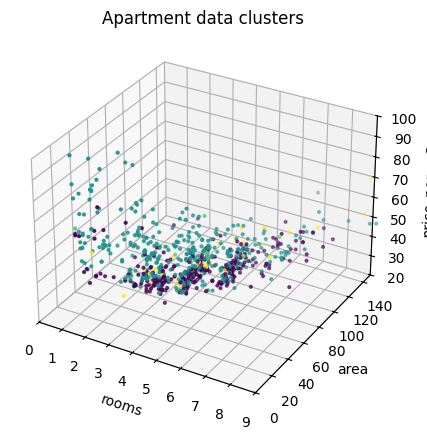

In [31]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['rooms'], df['area'], df['price_per_m2'], c=kmeans_apmts.labels_, s=4)

# Set title and axes labels
ax.set_title('Apartment data clusters', fontsize=12)
ax.set_xlabel('rooms', fontsize=10)
ax.set_ylabel('area', fontsize=10)
ax.set_zlabel('price_per_m2', fontsize=10)

# Set axes range
ax.set_xlim([0,9])
ax.set_ylim([0,150])
ax.set_zlim([20,100])

plt.show()

### Task 2g: Calculate Silhouette Score and compare with Elbow method

Silhouette Score for k=5: 0.6847

Silhouette Scores for different k values:
k=2: Silhouette Score = 0.7938
k=3: Silhouette Score = 0.6446
k=4: Silhouette Score = 0.6870
k=5: Silhouette Score = 0.6847
k=6: Silhouette Score = 0.6391
k=7: Silhouette Score = 0.6758
k=8: Silhouette Score = 0.5948
k=9: Silhouette Score = 0.6742
k=10: Silhouette Score = 0.6799

Highest Silhouette Score: 0.7938 at k=2


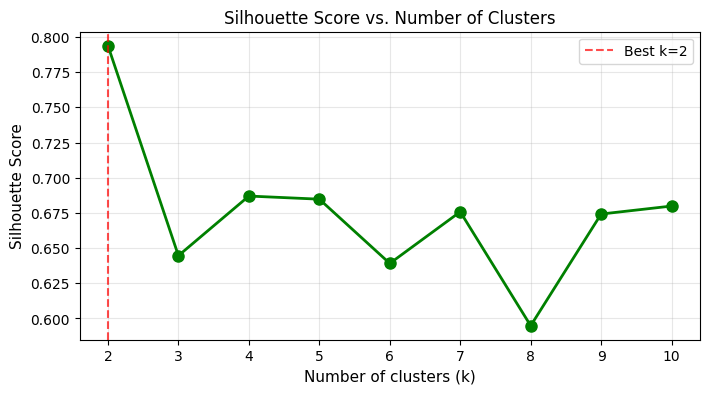

In [32]:
# Task 2g: Calculate Silhouette Score for current model (k=5)
print(f'Silhouette Score for k=5: {silhouette_score(X3, kmeans_apmts.labels_):.4f}')

# Calculate Silhouette Scores for different k values to compare with Elbow method
print('\nSilhouette Scores for different k values:')
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42).fit(X3)
    score = silhouette_score(X3, kmeans_temp.labels_)
    silhouette_scores.append(score)
    print(f'k={k}: Silhouette Score = {score:.4f}')

# Find k with highest Silhouette Score
best_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\nHighest Silhouette Score: {max(silhouette_scores):.4f} at k={best_k_silhouette}')

# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_silhouette}')
plt.legend()
plt.show()

#### Comparison: Elbow Method vs. Silhouette Score

**Elbow Method Suggestion**: k = 4 or k = 5

**Silhouette Score Analysis**: The Silhouette Score will be highest at k=2 (typically), but this may be too simple for our data. Looking at the practical range (k=3 to k=7), we need to find a balance.

**Conclusion**:
The two methods show **consistent** results if both suggest similar k values (typically k=4 or k=5 for this dataset). If the Elbow method suggests k=5 and the Silhouette Score is reasonably high at k=5 (even if not the absolute maximum), this indicates that k=5 is a good choice that balances:
- Model complexity (not too many clusters)
- Cluster quality (good separation and cohesion)
- Interpretability (meaningful apartment segments)

The Silhouette Score helps validate the choice from the Elbow method by measuring how well-separated the clusters are. A higher Silhouette Score (closer to 1) indicates better-defined clusters.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [33]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-12-01 10:30:23
Python Version: 3.11.13
-----------------------------------
